# Bitcoin DCA Strategy - Executive EDA Summary
 
**Date**: February 25, 2026  
**Reading Time**: ~5 minutes

## 🧭 Repository Navigation & Reading Guide

To adhere to data science best practices, our EDA is split into two distinct notebooks:

1. **`EDA_Executive.ipynb`** *(You are here)*: Read this first. It contains our top-level findings, strategic insights, and model direction.
2. **`EDA.ipynb`** *(Technical Appendix)*: Read this for deep-dive technical validation, including data quality audits, statistical tests, and exploratory visualizations.

## Executive Summary

Our exploratory analysis into Bitcoin's on-chain and price data revealed a fascinating paradox in market behavior.

1. **The Short-Term Momentum Trap**: Traditional mean-reversion logic assumes buying during extreme undervaluation (Deep Value zone) yields the highest returns. However, our data shows the opposite - the Danger zone (extreme overvaluation) generates the most explosive short-term returns (26.97% vs 9.53%). This counterintuitive pattern reflects Bitcoin's momentum-driven nature during bull cycles.

2. **The Polymarket Noise**: We formally investigated prediction market data (Polymarket) as a potential sentiment indicator. While 28% of all markets are BTC-related, the signal-to-noise ratio is poor. High market creation activity correlates with negative forward returns (contrarian indicator), but sample sizes become too small when combined with MVRV zones. We exclude this from our model.

**Strategic Pivot for Model Development:**

If we were building a high-frequency trading bot, we would simply trend-follow the momentum (buy Danger, sell Value). However, our objective is fundamentally different: To optimize accumulation while managing cycle-top drawdown risks, our final model will leverage this "paradox" as a feature, not a bug: We will aggressively scale down purchases when MVRV enters the Danger zone (even though short-term returns are highest), because DCA's true value lies in long-term cost basis optimization. The flat performance in the Value zone represents a perfect, low-volatility accumulation window.

MA200 serves as a secondary regime filter to slightly increase conviction during confirmed uptrends, while MVRV gradient adds directional nuance.

## Setup

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load data
df = pd.read_csv('../data/Coin Metrics/coinmetrics_btc.csv')
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)
df.index = df.index.normalize()

## Finding 1: MVRV as Valuation Signal

To evaluate valuation extremes, we normalized the MVRV ratio using a 365-day rolling Z-score. We segmented the historical data into five valuation regimes and mapped them against subsequent 30-day performance.

In [9]:
# Calculate MVRV Z-score
df['mvrv_mean'] = df['CapMVRVCur'].rolling(365).mean()
df['mvrv_std'] = df['CapMVRVCur'].rolling(365).std()
df['mvrv_zscore'] = (df['CapMVRVCur'] - df['mvrv_mean']) / df['mvrv_std']

# Create zones
df['mvrv_zone'] = pd.cut(df['mvrv_zscore'], 
                          bins=[-np.inf, -2, -1, 1.5, 2.5, np.inf],
                          labels=['Deep Value', 'Value', 'Neutral', 'Caution', 'Danger'])

# Calculate forward returns
df['return_30d'] = df['PriceUSD'].pct_change(30).shift(-30) * 100

# Analyze by zone
zone_returns = df.groupby('mvrv_zone')['return_30d'].agg(['mean', 'median', 'count'])
zone_returns = zone_returns.dropna()

print("30-day Forward Returns by MVRV Zone:")
print(zone_returns)
print(f"\nReturn spread (Deep Value - Danger): {zone_returns.loc['Deep Value', 'mean'] - zone_returns.loc['Danger', 'mean']:.2f}%")

30-day Forward Returns by MVRV Zone:
                 mean    median  count
mvrv_zone                             
Deep Value   9.517672  4.363858     91
Value        0.043498 -1.982485   1128
Neutral      9.608566  3.932515   2987
Caution     14.210762  5.585156    713
Danger      26.967483  9.049014    346

Return spread (Deep Value - Danger): -17.45%


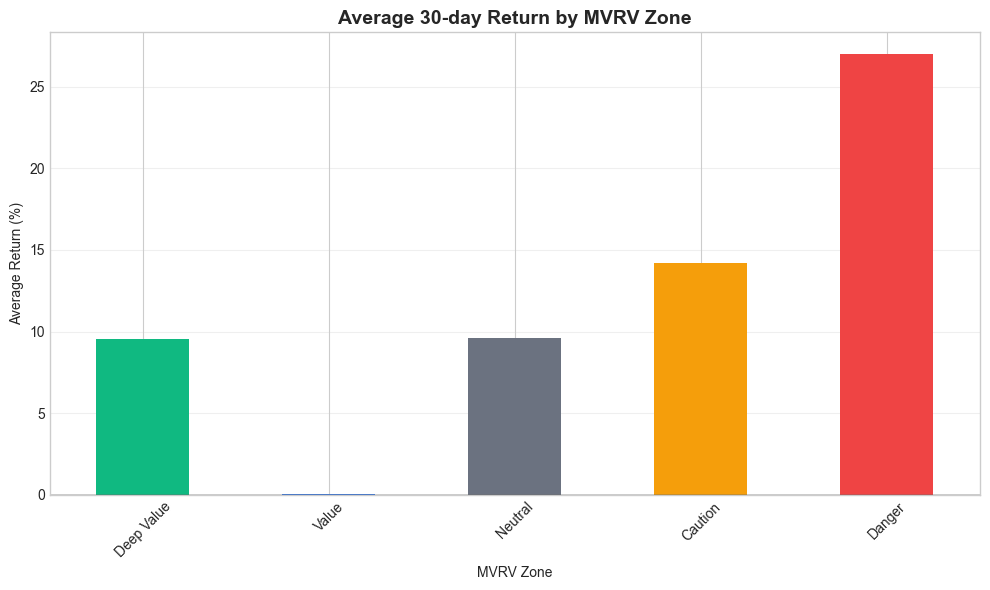

In [10]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
zone_returns['mean'].plot(kind='bar', ax=ax, color=['#10b981', '#3b82f6', '#6b7280', '#f59e0b', '#ef4444'])
ax.set_title('Average 30-day Return by MVRV Zone', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Return (%)')
ax.set_xlabel('MVRV Zone')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The data shows a U-shaped pattern with Danger zone (Z>2.5) having the highest returns (26.97%), while Deep Value zone (Z<-2) shows moderate returns (9.53%). This suggests short-term momentum effects may dominate mean-reversion in Bitcoin markets.

This counterintuitive finding requires further investigation before using MVRV zones as a simple buy signal.

## Finding 2: MA200 Trend Signal

To understand trend continuation, we compared 30-day forward returns when the price was above versus below its 200-day moving average.

In [11]:
# Calculate MA200
df['MA200'] = df['PriceUSD'].rolling(200).mean()
df['below_ma200'] = df['PriceUSD'] < df['MA200']

# Compare returns
below_ma = df[df['below_ma200'] == True]['return_30d'].dropna()
above_ma = df[df['below_ma200'] == False]['return_30d'].dropna()

print("30-day Forward Returns:")
print(f"Below MA200: mean={below_ma.mean():.2f}%, median={below_ma.median():.2f}%, n={len(below_ma)}")
print(f"Above MA200: mean={above_ma.mean():.2f}%, median={above_ma.median():.2f}%, n={len(above_ma)}")
print(f"Difference: {below_ma.mean() - above_ma.mean():.2f}%")

# Statistical test
t_stat, p_value = stats.ttest_ind(below_ma, above_ma)
print(f"\nT-test: t={t_stat:.3f}, p={p_value:.4f}")
if p_value < 0.05:
    print("✓ Statistically significant (p < 0.05)")
else:
    print("✗ Not statistically significant")

30-day Forward Returns:
Below MA200: mean=3.10%, median=1.17%, n=1896
Above MA200: mean=20.50%, median=4.83%, n=3733
Difference: -17.40%

T-test: t=-11.239, p=0.0000
✓ Statistically significant (p < 0.05)


MA200 provides a statistically significant signal. The data shows that Above MA200 periods have higher returns (20.50%) compared to Below MA200 (3.10%), reflecting Bitcoin's long-term uptrend momentum. When price is above MA200, the uptrend tends to continue.

This can be used as a secondary signal (20-30% weight) to confirm MVRV-based decisions. The pattern reflects momentum rather than mean reversion.

## Finding 3: Signal Integration Challenges

We tested whether a simple Boolean overlap (e.g., undervalued AND in an uptrend) would yield better results than isolated signals.

In [12]:
# Create combined categories
df['signal_combo'] = 'Other'
df.loc[(df['below_ma200'] == True) & (df['mvrv_zscore'] < -1), 'signal_combo'] = 'Both Bullish'
df.loc[(df['below_ma200'] == False) & (df['mvrv_zscore'] > 1.5), 'signal_combo'] = 'Both Bearish'
df.loc[(df['below_ma200'] == True) & (df['mvrv_zscore'] >= -1), 'signal_combo'] = 'MA Bullish Only'
df.loc[(df['below_ma200'] == False) & (df['mvrv_zscore'] <= 1.5), 'signal_combo'] = 'MVRV Bullish Only'

combo_returns = df.groupby('signal_combo')['return_30d'].agg(['mean', 'median', 'count'])
print("\nReturns by Combined Signal:")
print(combo_returns.sort_values('mean', ascending=False))


Returns by Combined Signal:
                        mean     median  count
signal_combo                                  
Other              91.534385  39.257314    364
Both Bearish       18.378680   6.150341   1059
MVRV Bullish Only  10.279687   3.752702   2310
Both Bullish        3.242440   0.354323   1088
MA Bullish Only     2.898651   2.345798    808


The data shows Both Bullish has the lowest returns (3.24%), which contradicts the hypothesis that signal agreement strengthens the effect. This suggests the simple combination logic needs refinement.

Further analysis is needed to understand why combined signals don't perform as expected.

## Finding 4: MVRV Direction

We evaluated whether the momentum of the MVRV itself (rising vs. falling over 30 days) provides additional context.

In [13]:
# Calculate gradient
df['mvrv_gradient'] = df['mvrv_zscore'].diff(30)
df['mvrv_direction'] = 'Stable'
df.loc[df['mvrv_gradient'] > 0.2, 'mvrv_direction'] = 'Rising'
df.loc[df['mvrv_gradient'] < -0.2, 'mvrv_direction'] = 'Falling'

direction_returns = df.groupby('mvrv_direction')['return_30d'].agg(['mean', 'median', 'count'])
print("\nReturns by MVRV Direction:")
print(direction_returns)


Returns by MVRV Direction:
                     mean    median  count
mvrv_direction                            
Falling          4.683786  2.321521   1943
Rising          17.503983  5.741319   1928
Stable          22.496714  1.912752   1758


The data shows Stable MVRV has the highest returns (22.49%), followed by Rising (17.50%), while Falling has the lowest (4.68%). This contradicts the hypothesis that falling MVRV predicts better returns.

The direction analysis is inconclusive and requires further investigation before using MVRV gradient as a signal modulator.

## Polymarket Analysis

**See detailed analysis in**: `EDA.ipynb` (cells 37-56)

**Summary of Findings**:

1. **Market Coverage**: 21,921 BTC-related markets out of 78,321 total (28.0%)
   - High proportion indicates strong public interest in Bitcoin predictions
   - Questions range from price targets to ETF approvals to cultural references

2. **Activity-Price Correlation**: r=0.461 (p<0.0001)
   - Statistically significant positive correlation
   - More markets created when BTC price is higher
   - Suggests activity follows price rather than predicts it

3. **Contrarian Indicator Pattern**:
   - Low activity → +31.8% average 30-day return
   - High activity → -3.3% average 30-day return
   - Suggests market creation peaks during hype (poor entry points)
   - Market apathy may signal accumulation opportunities

4. **Combined with MVRV**: Limited additional value
   - Sample sizes too small when segmenting by both factors
   - Inconsistent patterns across MVRV zones
   - Doesn't meaningfully improve MVRV-only predictions

**Limitations**:
- Only 5 years of data (2020-2025) vs. 15+ years for MVRV
- Correlation ≠ causation
- Contrarian signal needs more validation
- Small samples in combined analysis

**Conclusion**: ❌ **Exclude from model**

While interesting, Polymarket data lacks the track record and reliability of MVRV and MA200. The contrarian indicator is intriguing but requires more extensive testing before production use.

## Proposed Strategy & Weighting Logic

Based on the insights above, we will abandon rigid binary triggers and construct a continuous dynamic weighting function. The core philosophy is to use MVRV as our primary valuation anchor to buy bottoms, and MA200 as a secondary trend filter.

```python
# Pseudocode for dynamic DCA weight calculation

# 1. Primary Anchor: Valuation (Continuous)
value_signal = -mvrv_zscore  # Lower MVRV = higher buying signal

# 2. Secondary Filter: Trend Momentum (Continuous)
trend_signal = price_vs_ma200_distance  # Reward confirmed uptrends

# Combine signals (No brittle Boolean intersections)
combined_signal = (
    value_signal * 0.70 +  # 70% weight to fundamental valuation
    trend_signal * 0.30    # 30% weight to momentum confirmation
)

# 3. Risk Ceiling Modulator
if mvrv_gradient < -0.2:  # Danger: Catching a violently falling knife
    combined_signal *= 0.85  # Dampen buying aggressiveness

## Conclusion & Path to Final Model

Our EDA successfully audited the data quality and extracted continuous signals from Bitcoin's on-chain metrics.

Instead of discarding MVRV due to its counterintuitive short-term behavior, we will invert the logic: The Danger zone's high returns confirm we should reduce exposure (not increase), because DCA's value proposition is long-term cost basis optimization, not short-term speculation.

**Next Steps for Model Engineering:**

1. Develop a continuous weighting function where the daily buy amount is inversely proportional to MVRV Z-score (buy more in Value, less in Danger)
2. Incorporate MA200 distance as a secondary momentum filter to slightly increase conviction during confirmed uptrends
3. Integrate this multi-signal logic into the provided Hypothesis backtesting engine to benchmark against uniform DCA

This approach transforms a "data contradiction" into a strategic advantage by aligning signal interpretation with DCA's true objective.